# Customer Churn Data Exploration

Initial data analysis and exploration of customer churn datasets.

In [1]:
import pandas as pd
import numpy as np

# Load the training dataset
train_df = pd.read_csv('/content/customer_churn_dataset-training-master.csv')
print(f"Training dataset shape: {train_df.shape}")
print("\nFirst few rows of training data:")
train_df.head()

Training dataset shape: (440833, 12)

First few rows of training data:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [2]:
# Load the testing dataset
test_df = pd.read_csv('/content/customer_churn_dataset-testing-master.csv')
print(f"Testing dataset shape: {test_df.shape}")
print("\nFirst few rows of testing data:")
test_df.head()

Testing dataset shape: (64374, 12)

First few rows of testing data:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [3]:
# Check for NULL values in training dataset
print("NULL values in training dataset:")
print(train_df.isnull().sum())
print(f"\nTotal NULL values: {train_df.isnull().sum().sum()}")
print(f"Percentage of NULL values: {(train_df.isnull().sum().sum() / (train_df.shape[0] * train_df.shape[1])) * 100:.2f}%")

NULL values in training dataset:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Total NULL values: 12
Percentage of NULL values: 0.00%


In [4]:
# Check for NULL values in testing dataset
print("NULL values in testing dataset:")
print(test_df.isnull().sum())
print(f"\nTotal NULL values: {test_df.isnull().sum().sum()}")
print(f"Percentage of NULL values: {(test_df.isnull().sum().sum() / (test_df.shape[0] * test_df.shape[1])) * 100:.2f}%")

NULL values in testing dataset:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Total NULL values: 0
Percentage of NULL values: 0.00%


In [5]:
# Basic info about the datasets
print("Training dataset info:")
print(train_df.info())
print("\n" + "="*50 + "\n")
print("Testing dataset info:")
print(test_df.info())

Training dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None


Testing dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12

In [6]:
# Find and display rows with NULL values in training dataset
null_rows = train_df[train_df.isnull().any(axis=1)]
print(f"Number of rows with NULL values: {len(null_rows)}")
print("\nRows with NULL values:")
null_rows

Number of rows with NULL values: 1

Rows with NULL values:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Drop rows with NULL values from training dataset
print(f"Training dataset shape before dropping NULL values: {train_df.shape}")
train_df = train_df.dropna()
print(f"Training dataset shape after dropping NULL values: {train_df.shape}")

Training dataset shape before dropping NULL values: (440832, 12)
Training dataset shape after dropping NULL values: (440832, 12)


In [8]:
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 43.7+ MB


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette("husl")

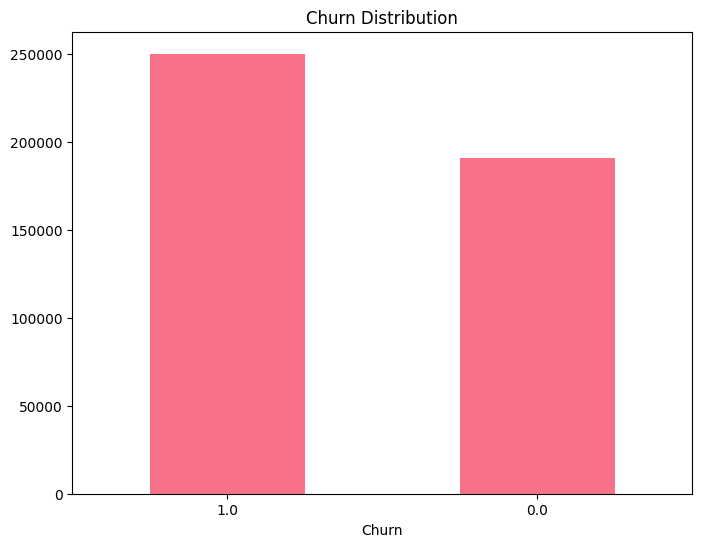

Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64


In [12]:
# Target variable distribution
plt.figure(figsize=(8, 6))
train_df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xticks(rotation=0)
plt.show()

# Churn rate percentage
churn_rate = train_df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

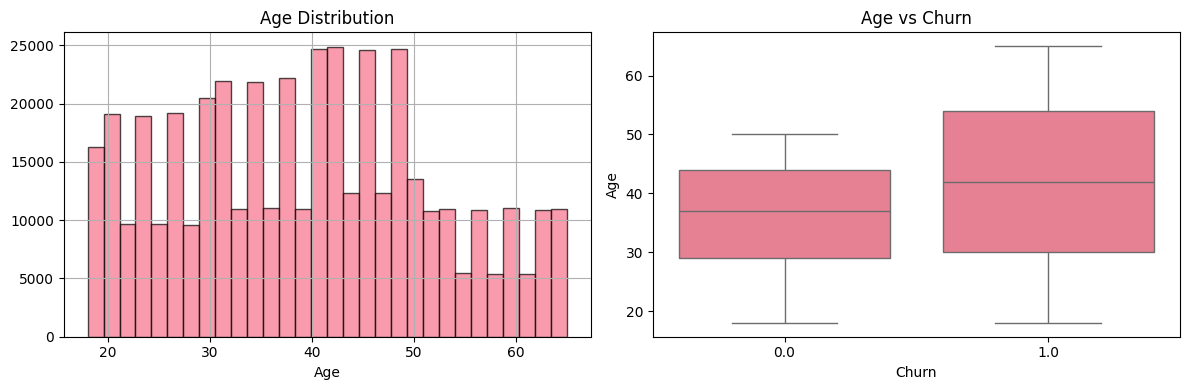

In [13]:
# Age distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
train_df['Age'].hist(bins=30, edgecolor='black', alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age')

plt.subplot(1, 2, 2)
sns.boxplot(data=train_df, x='Churn', y='Age')
plt.title('Age vs Churn')

plt.tight_layout()
plt.show()

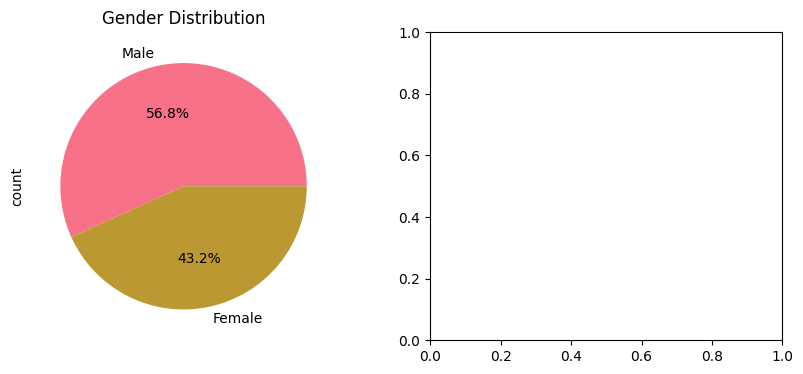

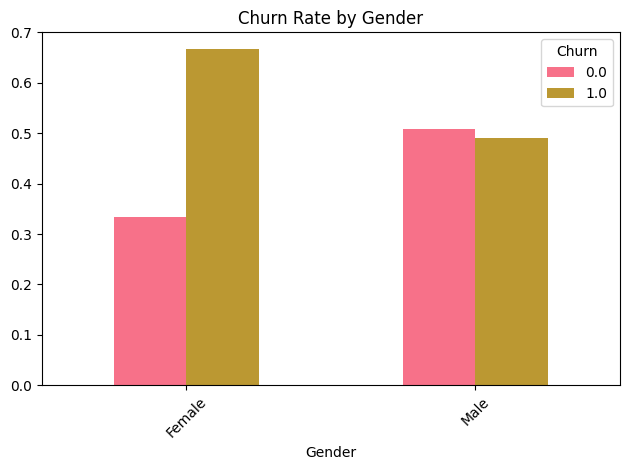

In [14]:
# Gender and churn relationship
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
train_df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender Distribution')

plt.subplot(1, 2, 2)
pd.crosstab(train_df['Gender'], train_df['Churn'], normalize='index').plot(kind='bar')
plt.title('Churn Rate by Gender')
plt.xticks(rotation=45)
plt.legend(title='Churn')

plt.tight_layout()
plt.show()

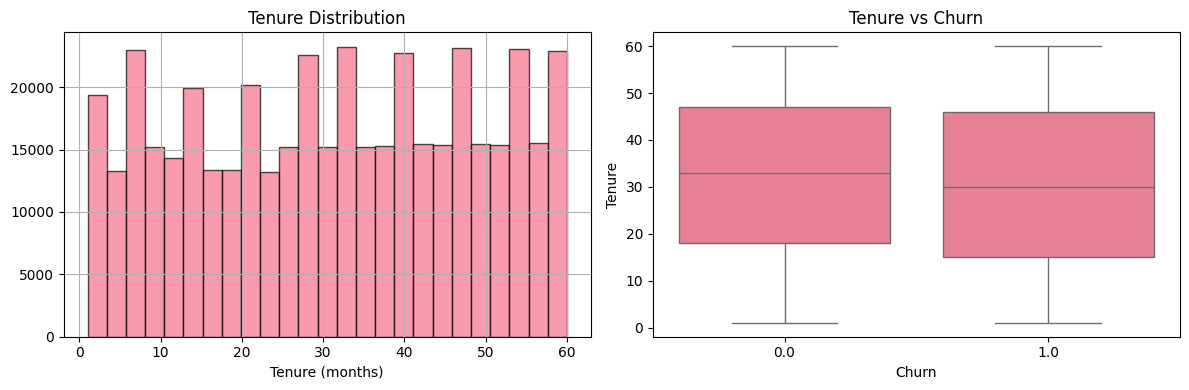

In [15]:
# Tenure analysis
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
train_df['Tenure'].hist(bins=25, edgecolor='black', alpha=0.7)
plt.title('Tenure Distribution')
plt.xlabel('Tenure (months)')

plt.subplot(1, 2, 2)
sns.boxplot(data=train_df, x='Churn', y='Tenure')
plt.title('Tenure vs Churn')

plt.tight_layout()
plt.show()

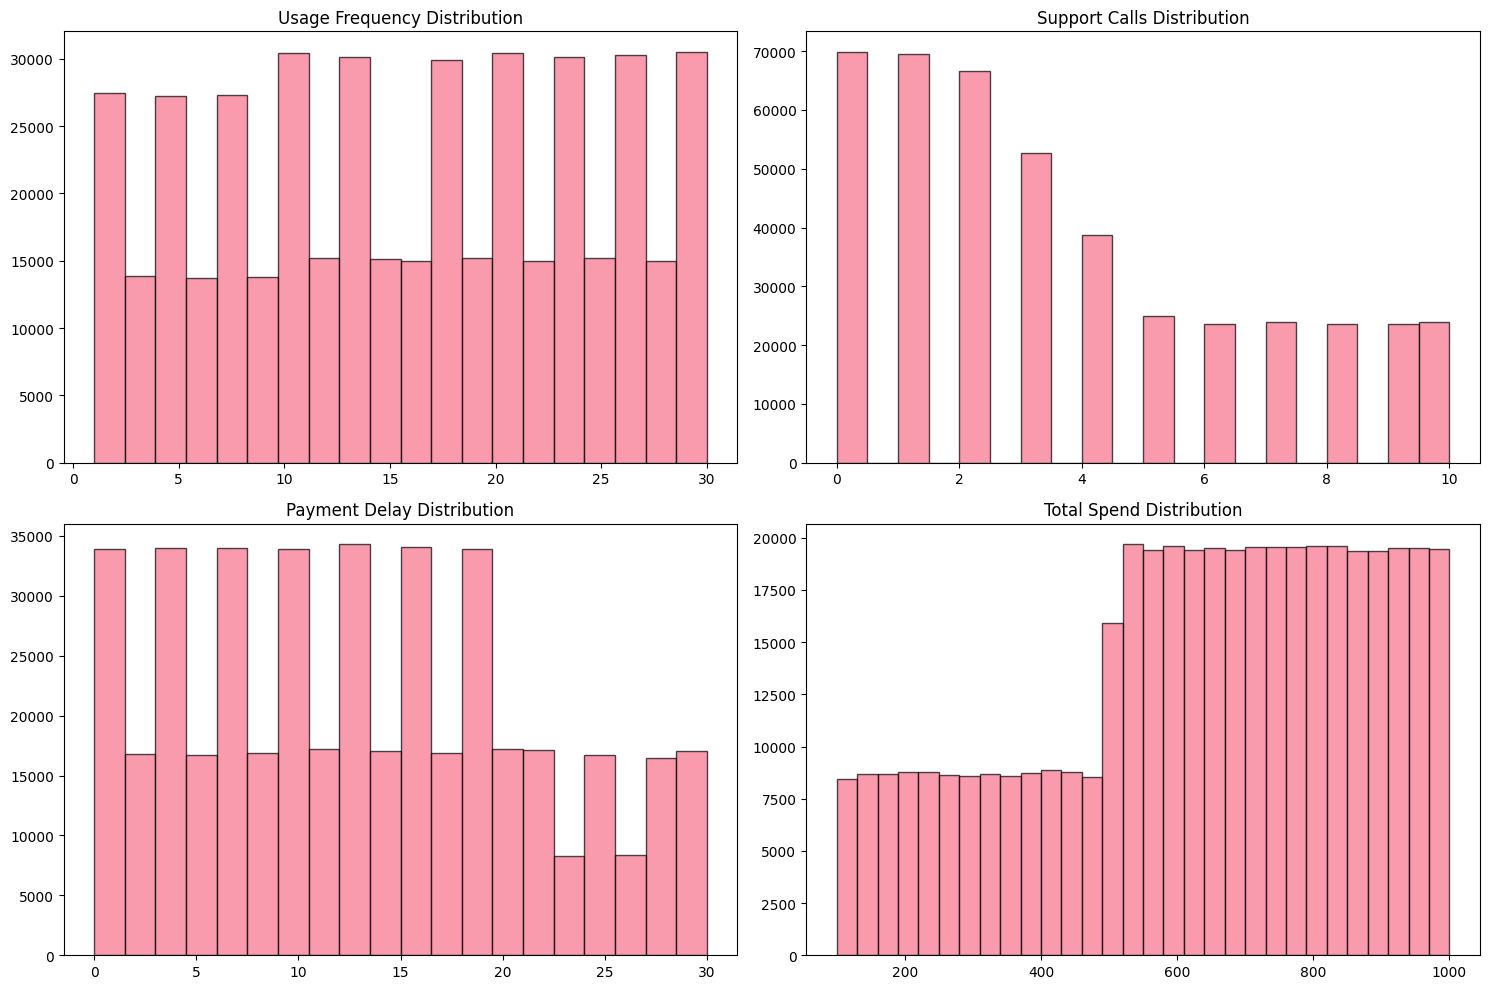

In [16]:
# Usage patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Usage Frequency
axes[0,0].hist(train_df['Usage Frequency'], bins=20, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Usage Frequency Distribution')

# Support Calls
axes[0,1].hist(train_df['Support Calls'], bins=20, edgecolor='black', alpha=0.7)
axes[0,1].set_title('Support Calls Distribution')

# Payment Delay
axes[1,0].hist(train_df['Payment Delay'], bins=20, edgecolor='black', alpha=0.7)
axes[1,0].set_title('Payment Delay Distribution')

# Total Spend
axes[1,1].hist(train_df['Total Spend'], bins=30, edgecolor='black', alpha=0.7)
axes[1,1].set_title('Total Spend Distribution')

plt.tight_layout()
plt.show()

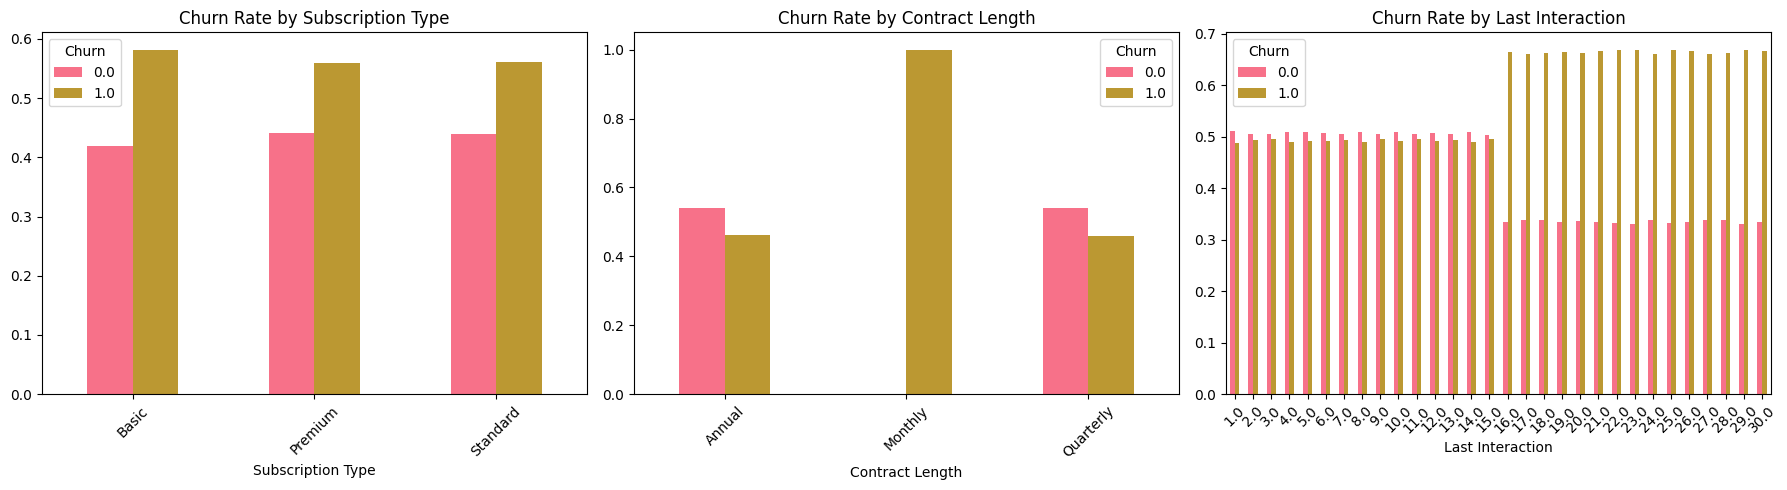

In [17]:
# Categorical features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subscription Type
pd.crosstab(train_df['Subscription Type'], train_df['Churn'], normalize='index').plot(kind='bar', ax=axes[0])
axes[0].set_title('Churn Rate by Subscription Type')
axes[0].set_xlabel('Subscription Type')
axes[0].tick_params(axis='x', rotation=45)

# Contract Length
pd.crosstab(train_df['Contract Length'], train_df['Churn'], normalize='index').plot(kind='bar', ax=axes[1])
axes[1].set_title('Churn Rate by Contract Length')
axes[1].set_xlabel('Contract Length')
axes[1].tick_params(axis='x', rotation=45)

# Last Interaction
pd.crosstab(train_df['Last Interaction'], train_df['Churn'], normalize='index').plot(kind='bar', ax=axes[2])
axes[2].set_title('Churn Rate by Last Interaction')
axes[2].set_xlabel('Last Interaction')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

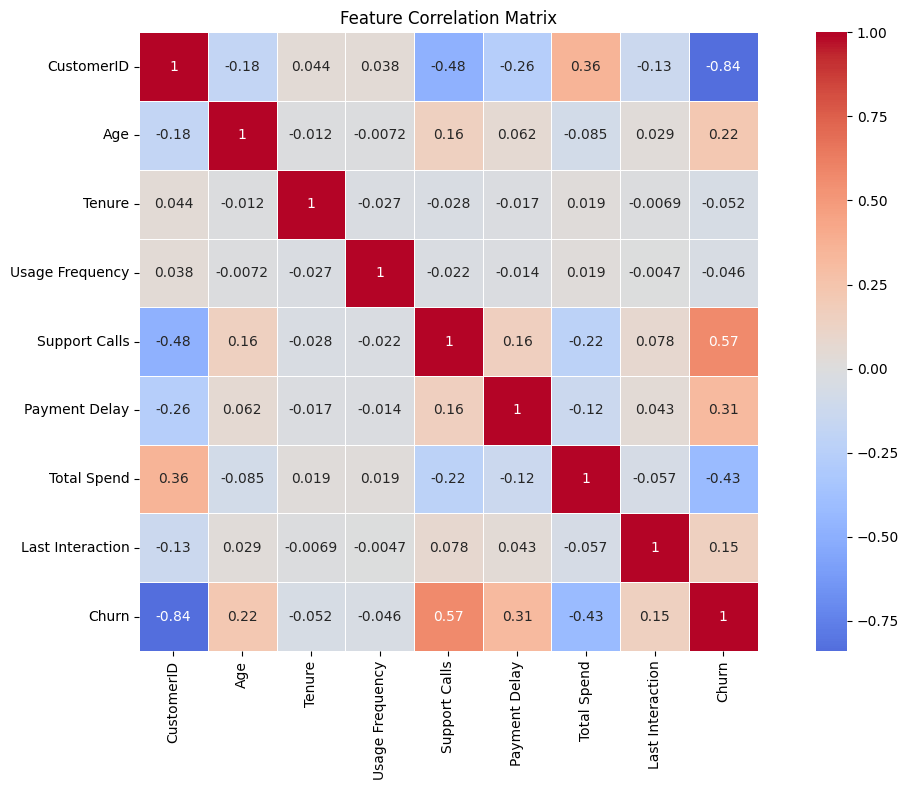

In [18]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
correlation_matrix = train_df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

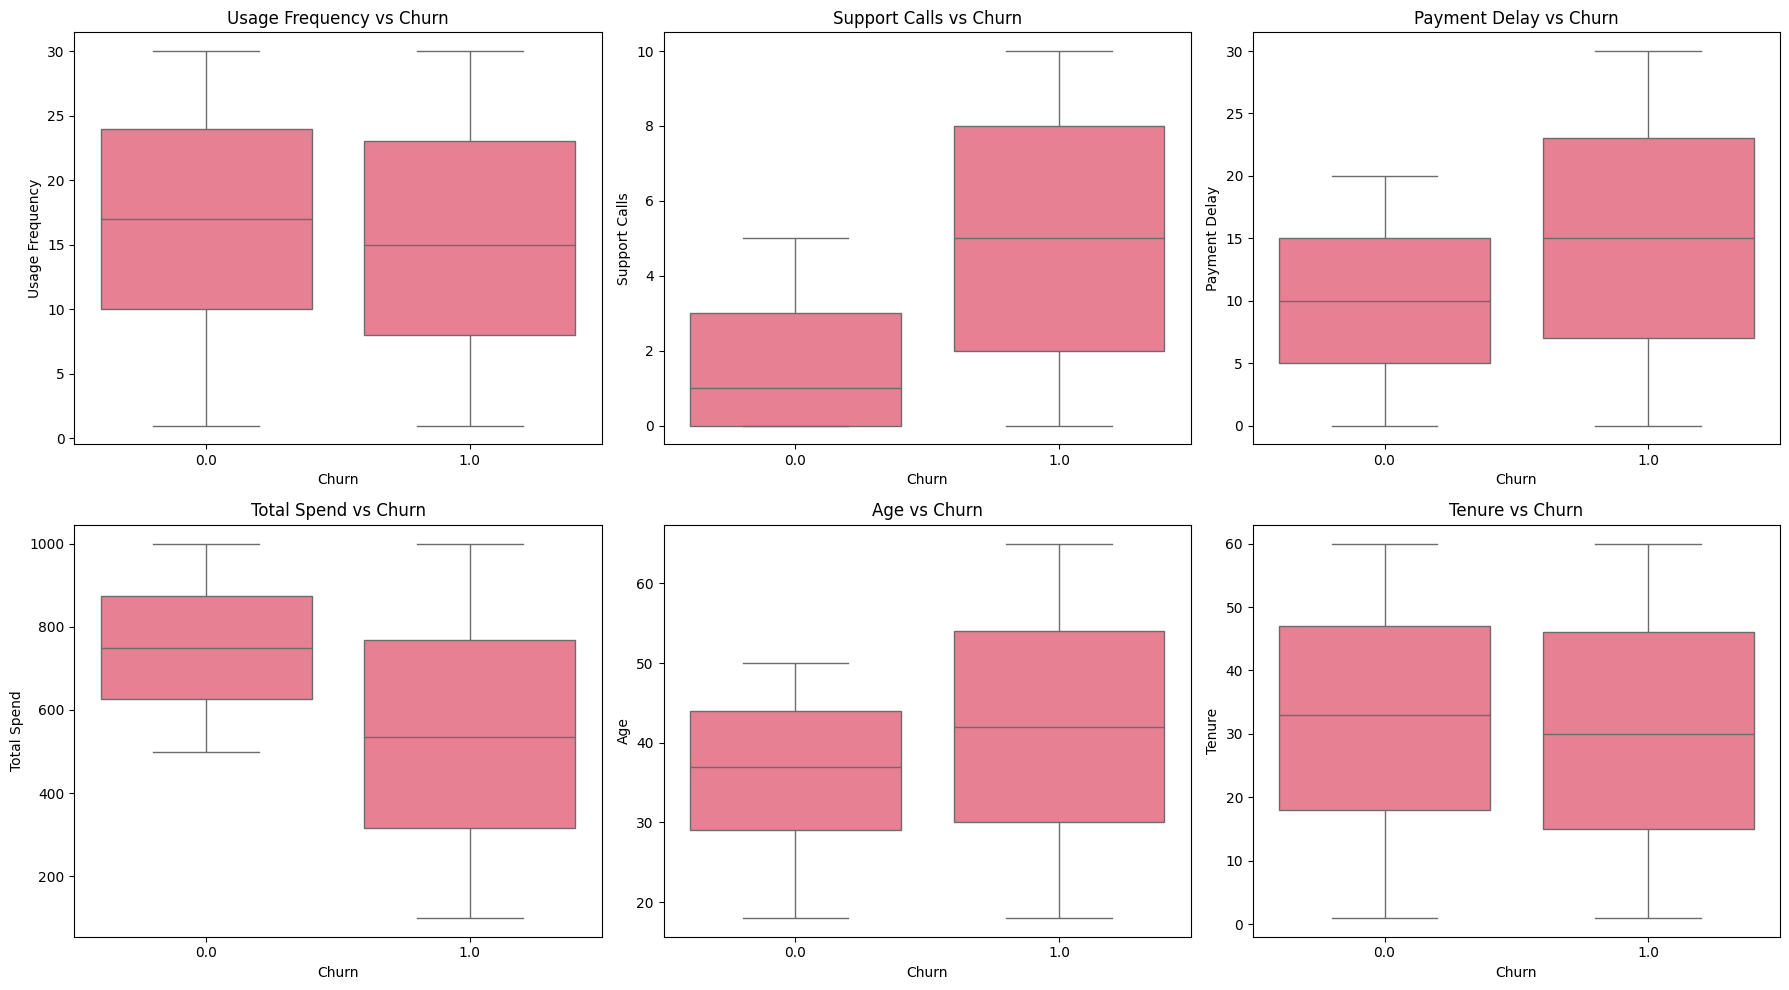

In [19]:
# Numerical features vs Churn - boxplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.boxplot(data=train_df, x='Churn', y='Usage Frequency', ax=axes[0,0])
axes[0,0].set_title('Usage Frequency vs Churn')

sns.boxplot(data=train_df, x='Churn', y='Support Calls', ax=axes[0,1])
axes[0,1].set_title('Support Calls vs Churn')

sns.boxplot(data=train_df, x='Churn', y='Payment Delay', ax=axes[0,2])
axes[0,2].set_title('Payment Delay vs Churn')

sns.boxplot(data=train_df, x='Churn', y='Total Spend', ax=axes[1,0])
axes[1,0].set_title('Total Spend vs Churn')

sns.boxplot(data=train_df, x='Churn', y='Age', ax=axes[1,1])
axes[1,1].set_title('Age vs Churn')

sns.boxplot(data=train_df, x='Churn', y='Tenure', ax=axes[1,2])
axes[1,2].set_title('Tenure vs Churn')

plt.tight_layout()
plt.show()

In [20]:
########################Value Encoding################################################

In [33]:
# Feature encoding - convert categorical variables to numeric
from sklearn.preprocessing import LabelEncoder

# Create copies of the datasets for processing
train_processed = train_df.copy()
test_processed = test_df.copy()

# Remove NULL rows
train_processed = train_processed.dropna()
test_processed = test_processed.dropna()

print("Categorical columns and their unique values:")
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length', 'Last Interaction', 'Churn']
for col in categorical_cols:
    print(f"{col}: {sorted(train_processed[col].unique())}")
print()

Categorical columns and their unique values:
Gender: ['Female', 'Male']
Subscription Type: ['Basic', 'Premium', 'Standard']
Contract Length: ['Annual', 'Monthly', 'Quarterly']
Last Interaction: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0)]
Churn: [np.float64(0.0), np.float64(1.0)]



In [34]:
# Label encoding for binary and nominal categorical variables
le_gender = LabelEncoder()
train_processed['Gender'] = le_gender.fit_transform(train_processed['Gender'])

le_subscription = LabelEncoder()
train_processed['Subscription Type'] = le_subscription.fit_transform(train_processed['Subscription Type'])

le_interaction = LabelEncoder()
train_processed['Last Interaction'] = le_interaction.fit_transform(train_processed['Last Interaction'])

# Ordinal encoding for Contract Length (assuming Monthly < Annual)
contract_mapping = {'Monthly': 0, 'Quarterly': 1, 'Annual': 2}
train_processed['Contract Length'] = train_processed['Contract Length'].map(contract_mapping)

# Encode target variable
le_churn = LabelEncoder()
train_processed['Churn'] = le_churn.fit_transform(train_processed['Churn'])

print("Encoding mappings:")
print(f"Gender: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")
print(f"Subscription Type: {dict(zip(le_subscription.classes_, le_subscription.transform(le_subscription.classes_)))}")
print(f"Last Interaction: {dict(zip(le_interaction.classes_, le_interaction.transform(le_interaction.classes_)))}")
print(f"Contract Length: {contract_mapping}")
print(f"Churn: {dict(zip(le_churn.classes_, le_churn.transform(le_churn.classes_)))}")

Encoding mappings:
Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Subscription Type: {'Basic': np.int64(0), 'Premium': np.int64(1), 'Standard': np.int64(2)}
Last Interaction: {np.float64(1.0): np.int64(0), np.float64(2.0): np.int64(1), np.float64(3.0): np.int64(2), np.float64(4.0): np.int64(3), np.float64(5.0): np.int64(4), np.float64(6.0): np.int64(5), np.float64(7.0): np.int64(6), np.float64(8.0): np.int64(7), np.float64(9.0): np.int64(8), np.float64(10.0): np.int64(9), np.float64(11.0): np.int64(10), np.float64(12.0): np.int64(11), np.float64(13.0): np.int64(12), np.float64(14.0): np.int64(13), np.float64(15.0): np.int64(14), np.float64(16.0): np.int64(15), np.float64(17.0): np.int64(16), np.float64(18.0): np.int64(17), np.float64(19.0): np.int64(18), np.float64(20.0): np.int64(19), np.float64(21.0): np.int64(20), np.float64(22.0): np.int64(21), np.float64(23.0): np.int64(22), np.float64(24.0): np.int64(23), np.float64(25.0): np.int64(24), np.float64(26.0): np.int64(25), np.fl

In [35]:
# Apply same preprocessing to test data
test_processed = test_processed.dropna()

# Apply same encodings to test data
test_processed['Gender'] = le_gender.transform(test_processed['Gender'])
test_processed['Subscription Type'] = le_subscription.transform(test_processed['Subscription Type'])
test_processed['Last Interaction'] = le_interaction.transform(test_processed['Last Interaction'])
test_processed['Contract Length'] = test_processed['Contract Length'].map(contract_mapping)
test_processed['Churn'] = le_churn.transform(test_processed['Churn'])

print("Both training and test datasets now have all categorical variables encoded to numeric values")
print(f"Training data shape: {train_processed.shape}")
print(f"Test data shape: {test_processed.shape}")

Both training and test datasets now have all categorical variables encoded to numeric values
Training data shape: (440832, 12)
Test data shape: (64374, 12)


In [36]:
train_df['Contract Length'].unique()

array(['Annual', 'Monthly', 'Quarterly'], dtype=object)

In [37]:
test_df['Contract Length'].unique()

array(['Monthly', 'Annual', 'Quarterly'], dtype=object)

In [38]:
train_processed.head(20)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,0,39.0,14.0,5.0,18.0,2,2,932.0,16,1
1,3.0,65.0,0,49.0,1.0,10.0,8.0,0,0,557.0,5,1
2,4.0,55.0,0,14.0,4.0,6.0,18.0,0,1,185.0,2,1
3,5.0,58.0,1,38.0,21.0,7.0,7.0,2,0,396.0,28,1
4,6.0,23.0,1,32.0,20.0,5.0,8.0,0,0,617.0,19,1
5,8.0,51.0,1,33.0,25.0,9.0,26.0,1,2,129.0,7,1
6,9.0,58.0,0,49.0,12.0,3.0,16.0,2,1,821.0,23,1
7,10.0,55.0,0,37.0,8.0,4.0,15.0,1,2,445.0,29,1
8,11.0,39.0,1,12.0,5.0,7.0,4.0,2,1,969.0,12,1
9,12.0,64.0,0,3.0,25.0,2.0,11.0,2,1,415.0,28,1


In [40]:
train_processed.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [42]:
test_processed.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [43]:
# Prepare data for model training
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Drop CustomerID from both datasets
X_train = train_processed.drop(['CustomerID', 'Churn'], axis=1)
y_train = train_processed['Churn']

X_test = test_processed.drop(['CustomerID', 'Churn'], axis=1)
y_test = test_processed['Churn']

print("Feature columns for model:")
print(X_train.columns.tolist())
print(f"\nTraining features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Test target shape: {y_test.shape}")

Feature columns for model:
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']

Training features shape: (440832, 10)
Training target shape: (440832,)
Test features shape: (64374, 10)
Test target shape: (64374,)


In [44]:
# Train logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Logistic regression model trained successfully!")
print(f"Model coefficients: {model.coef_[0]}")
print(f"Model intercept: {model.intercept_[0]}")

Logistic regression model trained successfully!
Model coefficients: [ 0.03475853 -1.0834429  -0.00712656 -0.01408527  0.70720752  0.1049667
 -0.05740567 -1.34214655 -0.00561925  0.05659352]
Model intercept: 1.3959491503158235


In [45]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.5791

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.21      0.35     33881
           1       0.53      0.99      0.69     30493

    accuracy                           0.58     64374
   macro avg       0.74      0.60      0.52     64374
weighted avg       0.75      0.58      0.51     64374


Confusion Matrix:
[[ 7160 26721]
 [  373 30120]]
